# Deep Learning for Malaria Diagnosis
Malaria remains a deadly crisis, and making manual microscopy difficult due to a severe shortage of trained specialists (Rajaraman et al., 2018). Automating thsi process can help a lot. This notebook builds a custom ResNet CNN to classify cell images as parasitized or uninfected. We utilize the benchmark NIH/NLM dataset containing 27,558 segmented cell images, perfectly balanced with 13,779 images per class. The architecture is a completely custom ResNet built from scratch using Keras Subclassing. We use a 70/15/15 stratified split (seed 42) with 128 × 128 inputs to run 7 experiments tracked via TensorBoard. Follow the sections in order: Configuration, Data Exploration, Model, Tooling, Experiments, Results, and Final Model.

## Configuration

In [1]:
# Use GPU: Please check if the outpout is '/device:GPU:0'
import tensorflow as tf
print(tf.__version__)
tf.test.gpu_device_name()
#from tensorflow.python.client import device_lib
#device_lib.list_local_devices()

2.20.0


I0000 00:00:1791365681.543697      50 gpu_device.cc:2020] Created device /device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1791365681.547535      50 gpu_device.cc:2020] Created device /device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


'/device:GPU:0'

## Populating namespaces

In [6]:
# Importing basic libraries
import os
import random
import shutil
from matplotlib import pyplot
from matplotlib.image import imread
%matplotlib inline

# Importing the Keras libraries and packages
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Convolution2D as Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense

In [7]:
# Define the useful paths for data accessibility
ai_project = '.'
cell_images_dir = None
for root, dirs, files in os.walk("/kaggle/input"):
    if "Parasitized" in dirs and "Uninfected" in dirs:
        cell_images_dir = root
        break

print("Found dataset at:", cell_images_dir)
training_path = os.path.join(ai_project,'train')
testing_path = os.path.join(ai_project,'test')

Found dataset at: /kaggle/input/datasets/iarunava/cell-images-for-detecting-malaria/cell_images


## Prepare DataSet

### Loading the DataSet
The dataset is added as an input on Kaggle

# Data Exploration
loking at the dataset and figuring out what it looks like and it's content which will help us make a good custom model

In [8]:
import glob, collections

# The zip sometimes unpacks to cell_images/cell_images/, so check
print(os.listdir(cell_images_dir))

parasitized = sorted(glob.glob(os.path.join(cell_images_dir, "Parasitized", "*.png")))
uninfected  = sorted(glob.glob(os.path.join(cell_images_dir, "Uninfected",  "*.png")))
print("Parasitized:", len(parasitized))
print("Uninfected :", len(uninfected))

['Uninfected', 'Parasitized', 'cell_images']
Parasitized: 13779
Uninfected : 13779


listdir shows a nested cell_images folder and the counts check out (13,779 per class).

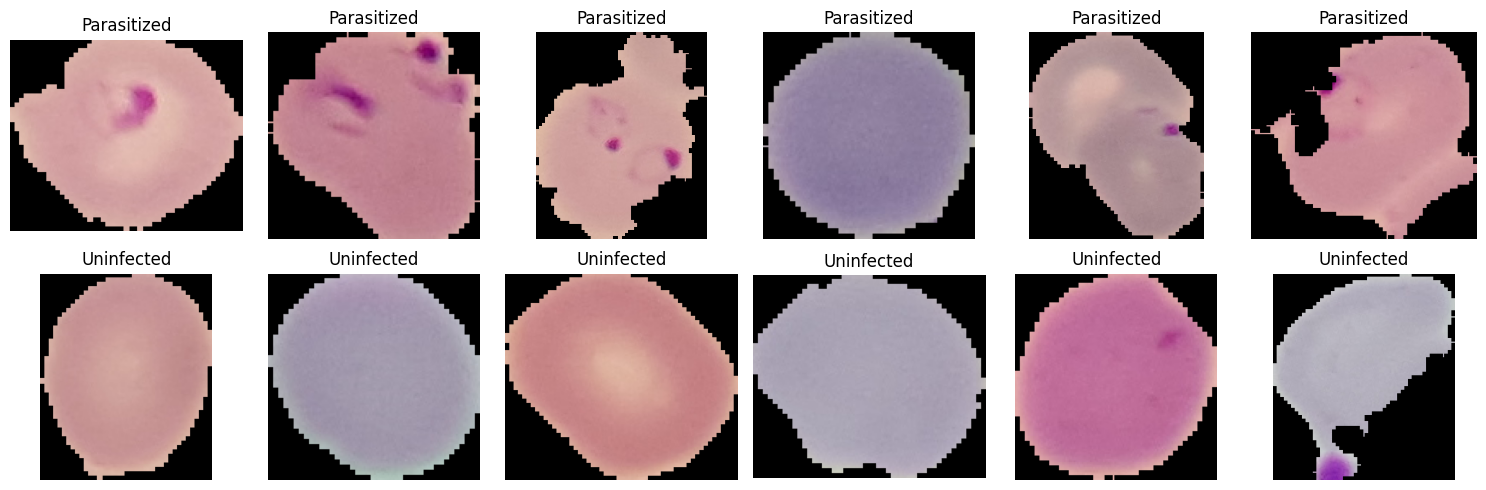

In [5]:
from matplotlib.image import imread

fig, axes = pyplot.subplots(2, 6, figsize=(15, 5))
for i in range(6):
    axes[0, i].imshow(imread(random.choice(parasitized)))
    axes[0, i].set_title("Parasitized"); axes[0, i].axis("off")
    axes[1, i].imshow(imread(random.choice(uninfected)))
    axes[1, i].set_title("Uninfected"); axes[1, i].axis("off")
pyplot.tight_layout(); pyplot.show()

In [9]:
from PIL import Image
sample = random.sample(parasitized + uninfected, 500)
sizes = [Image.open(p).size for p in sample]
widths, heights = zip(*sizes)
print("Width  min/mean/max:", min(widths), sum(widths)/len(widths), max(widths))
print("Height min/mean/max:", min(heights), sum(heights)/len(heights), max(heights))

Width  min/mean/max: 76 130.942 208
Height min/mean/max: 73 132.016 214


In [11]:
from sklearn.model_selection import train_test_split

SEED = 42
IMG_SIZE = 128   # confirm with the group
paths  = parasitized + uninfected
labels = [1]*len(parasitized) + [0]*len(uninfected)   # infected = 1 (positive class)

train_p, temp_p, train_y, temp_y = train_test_split(
    paths, labels, test_size=0.30, stratify=labels, random_state=SEED)
val_p, test_p, val_y, test_y = train_test_split(
    temp_p, temp_y, test_size=0.50, stratify=temp_y, random_state=SEED)

print(len(train_p), len(val_p), len(test_p))

19290 4134 4134


In [12]:
AUTOTUNE = tf.data.AUTOTUNE
BATCH_SIZE = 32

def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.resize_with_pad(img, IMG_SIZE, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    return img, tf.cast(label, tf.float32)

def make_ds(paths, labels, training=False, augment=None, batch_size=BATCH_SIZE):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(len(paths), seed=SEED)
    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)
    if training and augment is not None:
        ds = ds.map(lambda x, y: (augment(x, training=True), y),
                    num_parallel_calls=AUTOTUNE)
    return ds.batch(batch_size).prefetch(AUTOTUNE)

train_ds = make_ds(train_p, train_y, training=True)
val_ds   = make_ds(val_p,   val_y)
test_ds  = make_ds(test_p,  test_y)   # no shuffle, so predictions line up with test_y

I0000 00:00:1791365747.593934      50 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1791365747.595593      50 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


## Custom ResNet (built with Keras Subclassing)
`ResidualBlock` (a `Layer`) holds two 3×3 convolutions with BatchNorm and ReLU, plus a skip connection that adds the block's input to its output, `F(x) + x`. When the shape changes (more filters or stride 2), a 1×1 convolution projects the input so the two can be added. `CustomResNet` (a `Model`) stacks a stem convolution, the residual blocks, global average pooling, optional dropout, and a sigmoid output. The last feature map is returned when `return_feature_map=True`, so Grad-CAM can use it later. The default 3-block network ends at a 32×32×128 feature map. Trained from scratch, no pretrained weights.

In [13]:
class ResidualBlock(tf.keras.layers.Layer):
    def __init__(self, filters, stride=1, l2=0.0, use_skip=True, **kwargs):
        super().__init__(**kwargs)
        self.filters, self.stride, self.use_skip = filters, stride, use_skip
        self.reg = tf.keras.regularizers.l2(l2) if l2 > 0 else None
        self.conv1 = tf.keras.layers.Conv2D(filters, 3, stride, padding="same", kernel_regularizer=self.reg)
        self.bn1 = tf.keras.layers.BatchNormalization()
        self.conv2 = tf.keras.layers.Conv2D(filters, 3, 1, padding="same", kernel_regularizer=self.reg)
        self.bn2 = tf.keras.layers.BatchNormalization()
        self.relu = tf.keras.layers.ReLU()
        self.shortcut = None

    def build(self, input_shape):
        if self.use_skip and (self.stride != 1 or input_shape[-1] != self.filters):
            self.shortcut = tf.keras.layers.Conv2D(self.filters, 1, self.stride, kernel_regularizer=self.reg)
        super().build(input_shape)

    def call(self, x, training=False):
        y = self.relu(self.bn1(self.conv1(x), training=training))
        y = self.bn2(self.conv2(y), training=training)
        if not self.use_skip:                 # ablation: plain block, no F(x) + x
            return self.relu(y)
        s = x if self.shortcut is None else self.shortcut(x)
        return self.relu(y + s)


class CustomResNet(tf.keras.Model):
    def __init__(self, block_filters=(32, 64, 128), dropout=0.0, l2=0.0, use_skip=True, **kwargs):
        super().__init__(**kwargs)
        reg = tf.keras.regularizers.l2(l2) if l2 > 0 else None
        self.stem_conv = tf.keras.layers.Conv2D(32, 3, padding="same", kernel_regularizer=reg)
        self.stem_bn = tf.keras.layers.BatchNormalization()
        self.relu = tf.keras.layers.ReLU()
        # downsample (stride 2) whenever the filter count grows
        self.blocks = [ResidualBlock(f, stride=2 if (i > 0 and f != block_filters[i-1]) else 1,
                                     l2=l2, use_skip=use_skip)
                       for i, f in enumerate(block_filters)]
        self.gap = tf.keras.layers.GlobalAveragePooling2D()
        self.dropout = tf.keras.layers.Dropout(dropout)
        self.out = tf.keras.layers.Dense(1, activation="sigmoid")

    def call(self, x, training=False, return_feature_map=False):
        x = self.relu(self.stem_bn(self.stem_conv(x), training=training))
        for block in self.blocks:
            x = block(x, training=training)
        feature_map = x
        x = self.gap(feature_map)
        x = self.dropout(x, training=training)
        pred = self.out(x)
        return (feature_map, pred) if return_feature_map else pred

In [10]:
model = CustomResNet()
# model.build((None, IMG_SIZE, IMG_SIZE, 3))
fmap, pred = model(tf.zeros((1, IMG_SIZE, IMG_SIZE, 3)), return_feature_map=True)
print(fmap.shape, pred.shape)   # expect (1, 32, 32, 128) and (1, 1)
model.summary()

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy",
             tf.keras.metrics.Precision(name="precision"),
             tf.keras.metrics.Recall(name="recall"),
             tf.keras.metrics.AUC(name="auc")])

(1, 32, 32, 128) (1, 1)


Model: "custom_res_net"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (1, 128, 128, 32)      │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (1, 128, 128, 32)      │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_block (ResidualBlock)  │ ?                      │        18,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_block_1                │ ?                      │        58,048 │
│ (ResidualBlock)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_block_2                │ ?                      │       230,784 │
│ (ResidualBlock)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (1, 1)                 │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 308,737 (1.18 MB)

 Trainable params: 307,777 (1.17 MB)

 Non-trainable params: 960 (3.75 KB)

## Tooling

In [14]:
import datetime, numpy as np, pandas as pd
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix)
from tensorboard.plugins.hparams import api as hp

LOG_ROOT = "/kaggle/working/logs/fit"
# results = []

def evaluate(model, ds, y_true, threshold=0.5):
    probs = model.predict(ds, verbose=0).ravel()
    preds = (probs >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, preds).ravel()
    return {"accuracy": accuracy_score(y_true, preds),
            "precision": precision_score(y_true, preds),
            "recall": recall_score(y_true, preds),
            "specificity": tn / (tn + fp),
            "f1": f1_score(y_true, preds),
            "roc_auc": roc_auc_score(y_true, probs)}

def run_experiment(run_name, note, block_filters=(32, 64, 128), dropout=0.0, l2=0.0,
                   use_skip=True, lr=1e-3, lr_plateau=False, optimizer="adam",
                   batch_size=32, epochs=40, patience=8, augment=None, augment_desc="none"):
    log_dir = os.path.join(LOG_ROOT, run_name)
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(SEED)

    tr = make_ds(train_p, train_y, training=True, augment=augment, batch_size=batch_size)
    va = make_ds(val_p, val_y, batch_size=batch_size)

    model = CustomResNet(block_filters=block_filters, dropout=dropout, l2=l2, use_skip=use_skip)
    opt = {"adam": tf.keras.optimizers.Adam,
           "sgd": lambda lr: tf.keras.optimizers.SGD(lr, momentum=0.9)}[optimizer](lr)
    model.compile(optimizer=opt, loss="binary_crossentropy",
                  metrics=["accuracy", tf.keras.metrics.AUC(name="auc")])

    callbacks = [
        tf.keras.callbacks.TensorBoard(log_dir=log_dir),
        tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=patience,
                                         restore_best_weights=True),
    ]
    if lr_plateau:
        callbacks.append(tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6))

    history = model.fit(tr, validation_data=va, epochs=epochs, callbacks=callbacks)
    best_epoch = int(np.argmin(history.history["val_loss"])) + 1
    m = evaluate(model, va, val_y)

    hparams = {"architecture": "custom_resnet", "block_filters": str(block_filters),
               "n_blocks": len(block_filters), "skip_connections": use_skip,
               "dropout": dropout, "l2": l2, "learning_rate": lr,
               "lr_plateau": lr_plateau, "optimizer": optimizer, "batch_size": batch_size,
               "max_epochs": epochs, "patience": patience,
               "epochs_run": len(history.history["loss"]), "best_epoch": best_epoch,
               "augmentation": augment_desc, "transfer_strategy": "none (from scratch)"}
    with tf.summary.create_file_writer(os.path.join(log_dir, "hparams")).as_default():
        hp.hparams(hparams)
        for k, v in m.items():
            tf.summary.scalar(f"final_{k}", v, step=1)

    results.append({"run": run_name, "best_epoch": best_epoch,
                    "epochs_run": len(history.history["loss"]), **m, "note": note})
    pd.DataFrame(results).to_csv("/kaggle/working/results.csv", index=False)
    return model, history

## Model experiments
Each run changes one thing, and from exp 3 onward the changes are cumulative. Shared settings: 128×128 input, Adam, batch size 32, seed 42, up to 40 epochs, early stopping on validation loss (patience 8, best weights restored). All metrics below are on the **validation** set at threshold 0.5. The test set is kept for the final model only. Recall = sensitivity, and specificity = true-negative rate. Each run name matches its TensorBoard folder.

In [16]:
RESULTS_CSV = "/kaggle/working/results.csv"
results = pd.read_csv(RESULTS_CSV).to_dict("records") if os.path.exists(RESULTS_CSV) else []

def already_done(run_name):
    return any(r["run"] == run_name for r in results)

### Exp 1

In [14]:
model, history = run_experiment(
    "custom_resnet_exp_01_baseline",
    note="Small 3-block ResNet (32-64-128), Adam 1e-3, no augmentation, no dropout")
pd.DataFrame(results)

Epoch 1/40


2026-10-06 16:09:55.879316: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-06 16:09:56.033153: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-06 16:09:56.668944: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-06 16:09:56.834723: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-06 16:09:58.030408: E external/local_xla/xla/stream_

  1/603 ━━━━━━━━━━━━━━━━━━━━ 2:38:53 16s/step - accuracy: 0.3438 - auc: 0.5952 - loss: 1.3499

I0000 00:00:1791303002.984238     140 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


602/603 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.8312 - auc: 0.9009 - loss: 0.4001

2026-10-06 16:10:55.699149: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-06 16:10:55.851541: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-06 16:10:56.438562: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-06 16:10:56.605645: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-06 16:10:57.662865: E external/local_xla/xla/stream_

603/603 ━━━━━━━━━━━━━━━━━━━━ 88s 119ms/step - accuracy: 0.9017 - auc: 0.9597 - loss: 0.2764 - val_accuracy: 0.7789 - val_auc: 0.8095 - val_loss: 0.5891
Epoch 2/40
603/603 ━━━━━━━━━━━━━━━━━━━━ 46s 76ms/step - accuracy: 0.9444 - auc: 0.9801 - loss: 0.1742 - val_accuracy: 0.5784 - val_auc: 0.8350 - val_loss: 1.1149
Epoch 3/40
603/603 ━━━━━━━━━━━━━━━━━━━━ 45s 74ms/step - accuracy: 0.9494 - auc: 0.9830 - loss: 0.1562 - val_accuracy: 0.8953 - val_auc: 0.9704 - val_loss: 0.2632
Epoch 4/40
603/603 ━━━━━━━━━━━━━━━━━━━━ 46s 76ms/step - accuracy: 0.9502 - auc: 0.9844 - loss: 0.1493 - val_accuracy: 0.6052 - val_auc: 0.9333 - val_loss: 1.1598
Epoch 5/40
603/603 ━━━━━━━━━━━━━━━━━━━━ 46s 76ms/step - accuracy: 0.9516 - auc: 0.9856 - loss: 0.1457 - val_accuracy: 0.8515 - val_auc: 0.9144 - val_loss: 1.1620
Epoch 6/40
603/603 ━━━━━━━━━━━━━━━━━━━━ 46s 76ms/step - accuracy: 0.9548 - auc: 0.9867 - loss: 0.1381 - val_accuracy: 0.7603 - val_auc: 0.9521 - val_loss: 0.6049
Epoch 7/40
603/603 ━━━━━━━━━━━━━━━━━━━

,run,best_epoch,epochs_run,accuracy,precision,recall,specificity,f1,roc_auc,note
0,custom_resnet_exp_01_baseline,30,38,0.965409,0.980519,0.949686,0.981132,0.964856,0.991939,"Small 3-block ResNet (32-64-128), Adam 1e-3, n..."


### Exp 1: baseline (`custom_resnet_exp_01_baseline`)
**Setup:** 3 residual blocks (32-64-128), Adam 1e-3, no augmentation, no dropout, no L2.
**Result:** recall 0.9497, specificity 0.9811, F1 0.9649, AUC 0.9919. Stopped at epoch 38 (best epoch 30).
**Reading:** Already above the 90% target. After epoch 30, train loss kept falling while val loss rose (0.107 → 0.122), a mild overfitting sign. Recall is the weaker side (0.9497 vs 0.9811 specificity).

### Exp 2

In [15]:
augment_geo = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.25, fill_mode="constant", fill_value=0.0),  # ±90°
])

model, history = run_experiment(
    "custom_resnet_exp_02_augmentation_flip_rot",
    note="Exp 01 + random H/V flips and rotation up to ±90° (black fill)",
    augment=augment_geo, augment_desc="flip H+V, rotation ±90°")
pd.DataFrame(results)

Epoch 1/40
603/603 ━━━━━━━━━━━━━━━━━━━━ 82s 121ms/step - accuracy: 0.9018 - auc: 0.9586 - loss: 0.2779 - val_accuracy: 0.5890 - val_auc: 0.7376 - val_loss: 2.5877
Epoch 2/40
603/603 ━━━━━━━━━━━━━━━━━━━━ 66s 110ms/step - accuracy: 0.9448 - auc: 0.9802 - loss: 0.1712 - val_accuracy: 0.9122 - val_auc: 0.9764 - val_loss: 0.2300
Epoch 3/40
603/603 ━━━━━━━━━━━━━━━━━━━━ 65s 108ms/step - accuracy: 0.9506 - auc: 0.9833 - loss: 0.1544 - val_accuracy: 0.9410 - val_auc: 0.9810 - val_loss: 0.1850
Epoch 4/40
603/603 ━━━━━━━━━━━━━━━━━━━━ 65s 107ms/step - accuracy: 0.9518 - auc: 0.9833 - loss: 0.1516 - val_accuracy: 0.8474 - val_auc: 0.9650 - val_loss: 0.3937
Epoch 5/40
603/603 ━━━━━━━━━━━━━━━━━━━━ 64s 105ms/step - accuracy: 0.9537 - auc: 0.9856 - loss: 0.1415 - val_accuracy: 0.9562 - val_auc: 0.9866 - val_loss: 0.1672
Epoch 6/40
603/603 ━━━━━━━━━━━━━━━━━━━━ 62s 103ms/step - accuracy: 0.9538 - auc: 0.9858 - loss: 0.1417 - val_accuracy: 0.9478 - val_auc: 0.9837 - val_loss: 0.1723
Epoch 7/40
603/603 ━━━

,run,best_epoch,epochs_run,accuracy,precision,recall,specificity,f1,roc_auc,note
0,custom_resnet_exp_01_baseline,30,38,0.965409,0.980519,0.949686,0.981132,0.964856,0.991939,"Small 3-block ResNet (32-64-128), Adam 1e-3, n..."
1,custom_resnet_exp_02_augmentation_flip_rot,19,27,0.959603,0.967520,0.951137,0.968070,0.959258,0.991268,Exp 01 + random H/V flips and rotation up to ±...


### Exp 2: augmentation (`custom_resnet_exp_02_augmentation_flip_rot`)
**Change:** random horizontal/vertical flips and rotation up to ±90° (black fill), on training data only. Cells have no orientation, so this should add useful variety.
**Result:** recall 0.9511 (+0.14 pts), specificity 0.9681 (−1.30), F1 0.9593 (−0.56), AUC 0.9913. Stopped at epoch 27 (best epoch 19).
**Reading:** No measurable benefit, and slightly lower specificity. We don't conclude that augmentation hurts, only that it gave no gain here. A likely (untested) reason is that the cells are already segmented and centred on a black background. Augmentation is left out of the later runs.

**Decision:** augmentation is not carried forward, because exp 2 did not improve on exp 1. Exps 3 to 7 build on each other from here.

In [16]:
# Set after comparing exp 1 vs exp 2 (40-epoch budget): use augment_geo if it was not worse
BASE = dict(augment=None, augment_desc="none")
# BASE = dict(augment=augment_geo, augment_desc="flip H+V, rotation ±90°")

cfg3 = {**BASE, "lr": 5e-4, "lr_plateau": True}
cfg4 = {**cfg3, "dropout": 0.3}
cfg5 = {**cfg4, "l2": 1e-4}
cfg6 = {**cfg5, "block_filters": (32, 32, 64, 64, 128, 128)}
cfg7 = {**cfg6, "use_skip": False}

### Exp 3

In [17]:
model, history = run_experiment("custom_resnet_exp_03_lr_5e-4_plateau",
    note="Base + LR 5e-4 with ReduceLROnPlateau (x0.5, patience 3)", **cfg3)

Epoch 1/40
603/603 ━━━━━━━━━━━━━━━━━━━━ 62s 87ms/step - accuracy: 0.8984 - auc: 0.9597 - loss: 0.2815 - val_accuracy: 0.9395 - val_auc: 0.9827 - val_loss: 0.2033 - learning_rate: 5.0000e-04
Epoch 2/40
603/603 ━━━━━━━━━━━━━━━━━━━━ 46s 76ms/step - accuracy: 0.9482 - auc: 0.9842 - loss: 0.1561 - val_accuracy: 0.9023 - val_auc: 0.9516 - val_loss: 0.2762 - learning_rate: 5.0000e-04
Epoch 3/40
603/603 ━━━━━━━━━━━━━━━━━━━━ 45s 75ms/step - accuracy: 0.9521 - auc: 0.9858 - loss: 0.1450 - val_accuracy: 0.9296 - val_auc: 0.9853 - val_loss: 0.1940 - learning_rate: 5.0000e-04
Epoch 4/40
603/603 ━━━━━━━━━━━━━━━━━━━━ 45s 75ms/step - accuracy: 0.9546 - auc: 0.9867 - loss: 0.1379 - val_accuracy: 0.6860 - val_auc: 0.9197 - val_loss: 1.0155 - learning_rate: 5.0000e-04
Epoch 5/40
603/603 ━━━━━━━━━━━━━━━━━━━━ 45s 75ms/step - accuracy: 0.9565 - auc: 0.9883 - loss: 0.1307 - val_accuracy: 0.5900 - val_auc: 0.7672 - val_loss: 3.0443 - learning_rate: 5.0000e-04
Epoch 6/40
603/603 ━━━━━━━━━━━━━━━━━━━━ 45s 75ms/s

### Exp 3: lower LR + scheduler (`custom_resnet_exp_03_lr_5e-4_plateau`)
**Change vs exp 1:** learning rate 1e-3 → 5e-4, plus `ReduceLROnPlateau` (halve LR after 3 epochs without val-loss improvement, min 1e-6). Targets the noisy validation loss seen in exp 1.
**Result:** recall 0.9613 (+1.16 pts), specificity 0.9763 (−0.48), F1 0.9686 (+0.37), AUC 0.9936. Ran all 40 epochs (best epoch 38). The LR decayed to about 2e-6 by the end.
**Reading:** The first improvement, and the lowest best val loss (0.0974) of the runs without L2. It's a single seed, so treat the gain as suggestive.

### Exp 4

In [18]:
model, history = run_experiment("custom_resnet_exp_04_dropout_0.3",
    note="Exp 03 + dropout 0.3 before output", **cfg4)

Epoch 1/40
603/603 ━━━━━━━━━━━━━━━━━━━━ 61s 87ms/step - accuracy: 0.8976 - auc: 0.9579 - loss: 0.2829 - val_accuracy: 0.5847 - val_auc: 0.8413 - val_loss: 1.7332 - learning_rate: 5.0000e-04
Epoch 2/40
603/603 ━━━━━━━━━━━━━━━━━━━━ 45s 75ms/step - accuracy: 0.9456 - auc: 0.9810 - loss: 0.1711 - val_accuracy: 0.9245 - val_auc: 0.9862 - val_loss: 0.2106 - learning_rate: 5.0000e-04
Epoch 3/40
603/603 ━━━━━━━━━━━━━━━━━━━━ 45s 75ms/step - accuracy: 0.9515 - auc: 0.9845 - loss: 0.1485 - val_accuracy: 0.8713 - val_auc: 0.9656 - val_loss: 0.3136 - learning_rate: 5.0000e-04
Epoch 4/40
603/603 ━━━━━━━━━━━━━━━━━━━━ 45s 75ms/step - accuracy: 0.9529 - auc: 0.9859 - loss: 0.1428 - val_accuracy: 0.7765 - val_auc: 0.9646 - val_loss: 0.5037 - learning_rate: 5.0000e-04
Epoch 5/40
603/603 ━━━━━━━━━━━━━━━━━━━━ 45s 75ms/step - accuracy: 0.9548 - auc: 0.9869 - loss: 0.1366 - val_accuracy: 0.5007 - val_auc: 0.5077 - val_loss: 12.4440 - learning_rate: 5.0000e-04
Epoch 6/40
603/603 ━━━━━━━━━━━━━━━━━━━━ 45s 75ms/

### Exp 4: dropout (`custom_resnet_exp_04_dropout_0.3`)
**Change vs exp 3:** dropout 0.3 on the pooled feature vector, before the output layer.
**Result:** recall 0.9565 (−0.48 pts), specificity 0.9782 (+0.19), F1 0.9670 (−0.16), AUC 0.9928.
**Reading:** No measurable effect. A likely reason is that exp 3 was barely overfitting (train accuracy about 97.3% vs validation about 96.9%), so there was little to regularize.

### Exp 5

In [19]:
model, history = run_experiment("custom_resnet_exp_05_l2_1e-4",
    note="Exp 04 + L2 1e-4 on all conv kernels", **cfg5)

Epoch 1/40
603/603 ━━━━━━━━━━━━━━━━━━━━ 63s 88ms/step - accuracy: 0.8916 - auc: 0.9542 - loss: 0.3522 - val_accuracy: 0.9226 - val_auc: 0.9701 - val_loss: 0.3107 - learning_rate: 5.0000e-04
Epoch 2/40
603/603 ━━━━━━━━━━━━━━━━━━━━ 45s 74ms/step - accuracy: 0.9443 - auc: 0.9807 - loss: 0.2179 - val_accuracy: 0.6749 - val_auc: 0.9534 - val_loss: 0.7082 - learning_rate: 5.0000e-04
Epoch 3/40
603/603 ━━━━━━━━━━━━━━━━━━━━ 45s 74ms/step - accuracy: 0.9489 - auc: 0.9831 - loss: 0.1987 - val_accuracy: 0.9318 - val_auc: 0.9851 - val_loss: 0.2314 - learning_rate: 5.0000e-04
Epoch 4/40
603/603 ━━━━━━━━━━━━━━━━━━━━ 45s 75ms/step - accuracy: 0.9530 - auc: 0.9855 - loss: 0.1814 - val_accuracy: 0.5747 - val_auc: 0.9179 - val_loss: 1.4333 - learning_rate: 5.0000e-04
Epoch 5/40
603/603 ━━━━━━━━━━━━━━━━━━━━ 45s 74ms/step - accuracy: 0.9542 - auc: 0.9866 - loss: 0.1728 - val_accuracy: 0.7100 - val_auc: 0.9468 - val_loss: 0.7807 - learning_rate: 5.0000e-04
Epoch 6/40
603/603 ━━━━━━━━━━━━━━━━━━━━ 45s 74ms/s

### Exp 5: L2 (`custom_resnet_exp_05_l2_1e-4`)
**Change vs exp 4:** L2 penalty 1e-4 on every convolution kernel (stem, blocks, and shortcuts).
**Result:** recall 0.9594 (+0.29 pts), specificity 0.9768 (−0.14), F1 0.9678 (+0.08), AUC 0.9933.
**Reading:** No measurable effect. Note that Keras adds the L2 penalty to both train and val loss, so exp 5 to 7 losses (0.10 to 0.12) aren't comparable with exp 3 and 4 (about 0.10).

### Exp 6

In [20]:
model, history = run_experiment("custom_resnet_exp_06_deeper_6blocks",
    note="Exp 05 + 6 residual blocks (32-32-64-64-128-128)", **cfg6)

Epoch 1/40
603/603 ━━━━━━━━━━━━━━━━━━━━ 106s 152ms/step - accuracy: 0.9222 - auc: 0.9683 - loss: 0.3197 - val_accuracy: 0.9468 - val_auc: 0.9794 - val_loss: 0.3081 - learning_rate: 5.0000e-04
Epoch 2/40
603/603 ━━━━━━━━━━━━━━━━━━━━ 82s 136ms/step - accuracy: 0.9502 - auc: 0.9818 - loss: 0.2365 - val_accuracy: 0.9487 - val_auc: 0.9846 - val_loss: 0.2381 - learning_rate: 5.0000e-04
Epoch 3/40
603/603 ━━━━━━━━━━━━━━━━━━━━ 82s 135ms/step - accuracy: 0.9523 - auc: 0.9835 - loss: 0.2189 - val_accuracy: 0.9509 - val_auc: 0.9867 - val_loss: 0.2107 - learning_rate: 5.0000e-04
Epoch 4/40
603/603 ━━━━━━━━━━━━━━━━━━━━ 82s 135ms/step - accuracy: 0.9550 - auc: 0.9846 - loss: 0.2014 - val_accuracy: 0.6461 - val_auc: 0.7334 - val_loss: 2.9820 - learning_rate: 5.0000e-04
Epoch 5/40
603/603 ━━━━━━━━━━━━━━━━━━━━ 81s 135ms/step - accuracy: 0.9552 - auc: 0.9867 - loss: 0.1882 - val_accuracy: 0.9352 - val_auc: 0.9813 - val_loss: 0.2892 - learning_rate: 5.0000e-04
Epoch 6/40
603/603 ━━━━━━━━━━━━━━━━━━━━ 82s 

### Exp 6: deeper network (`custom_resnet_exp_06_deeper_6blocks`)
**Change vs exp 5:** 3 → 6 residual blocks (32-32-64-64-128-128). Stride 2 is applied only where the filter count grows, so the final feature map is still 32×32×128 and Grad-CAM keeps working.
**Result:** recall 0.9642, specificity 0.9768, F1 0.9703, AUC 0.9934, accuracy 0.9705. These are the best recall, F1, and accuracy of the seven runs. An epoch takes about 80 s vs about 45 s for 3 blocks.
**Reading:** Gains over exp 5 are small (+0.48 recall, +0.25 F1). After the best epoch, train loss fell while val loss rose, a mild overfitting sign. Selected as the final model, mainly for its recall, since a missed infection is the costlier error.

### Exp 7

In [21]:
model, history = run_experiment("custom_resnet_exp_07_deeper_no_skip_ablation",
    note="Exp 06 with skip connections removed (plain blocks)", **cfg7)

Epoch 1/40
603/603 ━━━━━━━━━━━━━━━━━━━━ 99s 142ms/step - accuracy: 0.9300 - auc: 0.9736 - loss: 0.2897 - val_accuracy: 0.9470 - val_auc: 0.9843 - val_loss: 0.2400 - learning_rate: 5.0000e-04
Epoch 2/40
603/603 ━━━━━━━━━━━━━━━━━━━━ 77s 127ms/step - accuracy: 0.9503 - auc: 0.9821 - loss: 0.2228 - val_accuracy: 0.9536 - val_auc: 0.9855 - val_loss: 0.2253 - learning_rate: 5.0000e-04
Epoch 3/40
603/603 ━━━━━━━━━━━━━━━━━━━━ 76s 126ms/step - accuracy: 0.9519 - auc: 0.9811 - loss: 0.2115 - val_accuracy: 0.9439 - val_auc: 0.9715 - val_loss: 0.2707 - learning_rate: 5.0000e-04
Epoch 4/40
603/603 ━━━━━━━━━━━━━━━━━━━━ 77s 128ms/step - accuracy: 0.9525 - auc: 0.9827 - loss: 0.1975 - val_accuracy: 0.9507 - val_auc: 0.9890 - val_loss: 0.1825 - learning_rate: 5.0000e-04
Epoch 5/40
603/603 ━━━━━━━━━━━━━━━━━━━━ 76s 126ms/step - accuracy: 0.9547 - auc: 0.9843 - loss: 0.1832 - val_accuracy: 0.9490 - val_auc: 0.9853 - val_loss: 0.1899 - learning_rate: 5.0000e-04
Epoch 6/40
603/603 ━━━━━━━━━━━━━━━━━━━━ 76s 1

### Exp 7: skip-connection ablation (`custom_resnet_exp_07_deeper_no_skip_ablation`)
**Change vs exp 6:** `use_skip=False`. Each block drops `F(x) + x` and its projection shortcut, leaving plain conv-BN-ReLU blocks. Everything else is identical, apart from the removed shortcut parameters.
**Result:** recall 0.9579 (−0.63 pts), specificity 0.9792 (+0.24), F1 0.9682 (−0.21), AUC 0.9940 (+0.0006).
**Reading:** A tie within noise, with a recall-for-specificity trade. At 12 convolutions with BatchNorm, we found no evidence that skips help. He et al. (2016) reported the degradation problem in much deeper plain networks (34+ layers), so this is consistent with theory. Caveat: single seed.

## Results

In [22]:
df = pd.DataFrame(results)
cols = ["run", "epochs_run", "best_epoch", "recall", "specificity", "precision", "f1", "roc_auc", "accuracy"]
df[cols].round(4)

,run,epochs_run,best_epoch,recall,specificity,precision,f1,roc_auc,accuracy
0,custom_resnet_exp_01_baseline,38,30,0.9497,0.9811,0.9805,0.9649,0.9919,0.9654
1,custom_resnet_exp_02_augmentation_flip_rot,27,19,0.9511,0.9681,0.9675,0.9593,0.9913,0.9596
2,custom_resnet_exp_03_lr_5e-4_plateau,40,38,0.9613,0.9763,0.9759,0.9686,0.9936,0.9688
3,custom_resnet_exp_04_dropout_0.3,40,36,0.9565,0.9782,0.9777,0.9670,0.9928,0.9673
4,custom_resnet_exp_05_l2_1e-4,40,34,0.9594,0.9768,0.9764,0.9678,0.9933,0.9681
5,custom_resnet_exp_06_deeper_6blocks,40,33,0.9642,0.9768,0.9765,0.9703,0.9934,0.9705
6,custom_resnet_exp_07_deeper_no_skip_ablation,40,34,0.9579,0.9792,0.9787,0.9682,0.9940,0.9686


All seven runs cleared 90% sensitivity and specificity. The spread across runs is small (accuracy 0.9596 to 0.9705, recall 0.9497 to 0.9642). Because one config's recall moved about 3.5 pts between an unseeded and a seeded run earlier in the project, differences of 1 to 2 pts are treated as within noise. The clearest change was exp 1 → exp 3 (learning-rate schedule).

## Final Model

In [17]:
FINAL_NAME = "custom_resnet_final_exp06_config"
FINAL_CFG = dict(block_filters=(32, 32, 64, 64, 128, 128), dropout=0.3, l2=1e-4,
                 lr=5e-4, lr_plateau=True, augment=None, augment_desc="none")

final_model, final_history = run_experiment(
    FINAL_NAME,
    note="Retrain of exp 06 config, keeps weights for test evaluation and Grad-CAM",
    **FINAL_CFG)

final_model.save_weights("/kaggle/working/final_resnet.weights.h5")
pd.DataFrame(final_history.history).to_csv("/kaggle/working/final_history.csv", index=False)
print({k: round(v, 4) for k, v in results[-1].items() if isinstance(v, float)})

Epoch 1/40


2026-10-07 09:37:50.782665: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-07 09:37:50.937879: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-07 09:37:51.962256: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-07 09:37:52.129574: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-07 09:37:53.306455: E external/local_xla/xla/stream_

602/603 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - accuracy: 0.8642 - auc: 0.9214 - loss: 0.4284

2026-10-07 09:39:51.272519: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-07 09:39:51.425492: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-07 09:39:52.322339: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-07 09:39:52.487855: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-07 09:39:53.479765: E external/local_xla/xla/stream_

603/603 ━━━━━━━━━━━━━━━━━━━━ 169s 242ms/step - accuracy: 0.9216 - auc: 0.9690 - loss: 0.3170 - val_accuracy: 0.9262 - val_auc: 0.9843 - val_loss: 0.3066 - learning_rate: 5.0000e-04
Epoch 2/40
603/603 ━━━━━━━━━━━━━━━━━━━━ 76s 126ms/step - accuracy: 0.9494 - auc: 0.9828 - loss: 0.2366 - val_accuracy: 0.9507 - val_auc: 0.9863 - val_loss: 0.2243 - learning_rate: 5.0000e-04
Epoch 3/40
603/603 ━━━━━━━━━━━━━━━━━━━━ 78s 128ms/step - accuracy: 0.9531 - auc: 0.9846 - loss: 0.2169 - val_accuracy: 0.6766 - val_auc: 0.8999 - val_loss: 1.0897 - learning_rate: 5.0000e-04
Epoch 4/40
603/603 ━━━━━━━━━━━━━━━━━━━━ 78s 129ms/step - accuracy: 0.9552 - auc: 0.9855 - loss: 0.2002 - val_accuracy: 0.9507 - val_auc: 0.9854 - val_loss: 0.2025 - learning_rate: 5.0000e-04
Epoch 5/40
603/603 ━━━━━━━━━━━━━━━━━━━━ 78s 130ms/step - accuracy: 0.9556 - auc: 0.9868 - loss: 0.1877 - val_accuracy: 0.8931 - val_auc: 0.9654 - val_loss: 0.4735 - learning_rate: 5.0000e-04
Epoch 6/40
603/603 ━━━━━━━━━━━━━━━━━━━━ 78s 130ms/step 

In [ ]:
probs = final_model.predict(test_ds, verbose=0).ravel()
y_test = np.array(test_y)
preds = (probs >= 0.5).astype(int)
test_metrics = evaluate(final_model, test_ds, test_y)
tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()
np.save("/kaggle/working/test_probs.npy", probs)
print(f"TP={tp}  FN={fn}  FP={fp}  TN={tn}")
pd.DataFrame([test_metrics]).round(4)

In [ ]:
from sklearn.metrics import roc_curve, ConfusionMatrixDisplay
h = final_history.history
ep = range(1, len(h["loss"]) + 1)
best = results[-1]["best_epoch"]

fig, ax = pyplot.subplots(1, 4, figsize=(22, 5))
ax[0].plot(ep, h["accuracy"], label="train"); ax[0].plot(ep, h["val_accuracy"], label="validation")
ax[0].axvline(best, color="gray", ls=":", label="best epoch")
ax[0].set(title="Accuracy", xlabel="epoch", ylabel="accuracy"); ax[0].legend()

ax[1].plot(ep, h["loss"], label="train"); ax[1].plot(ep, h["val_loss"], label="validation")
ax[1].axvline(best, color="gray", ls=":", label="best epoch")
ax[1].set(title="Loss (includes L2 penalty)", xlabel="epoch", ylabel="loss"); ax[1].legend()

ConfusionMatrixDisplay(confusion_matrix(y_test, preds),
                       display_labels=["Uninfected", "Parasitized"]).plot(ax=ax[2], colorbar=False)
ax[2].set_title("Confusion matrix (test)")

fpr, tpr, _ = roc_curve(y_test, probs)
ax[3].plot(fpr, tpr, label=f"AUC = {test_metrics['roc_auc']:.4f}")
ax[3].plot([0, 1], [0, 1], "k--", label="chance")
ax[3].scatter([fp / (fp + tn)], [tp / (tp + fn)], color="red", zorder=3, label="threshold 0.5")
ax[3].set(title="ROC curve (test)", xlabel="1 - specificity", ylabel="sensitivity"); ax[3].legend()

pyplot.tight_layout()
pyplot.savefig("/kaggle/working/final_four_plots.png", dpi=200)
pyplot.show()

In [ ]:
def get_image(path):
    img, _ = load_image(path, 0)          # same resize/pad the model saw
    return img.numpy()

def gradcam(model, img, target="predicted"):
    x = tf.convert_to_tensor(img[None, ...])
    with tf.GradientTape() as tape:
        fmap, pred = model(x, training=False, return_feature_map=True)
        p = pred[:, 0]
        pred_infected = float(p[0]) >= 0.5
        # explain the predicted class: P(infected) if infected, else 1 - P(infected)
        score = p if (target == "infected" or pred_infected) else 1.0 - p
    grads = tape.gradient(score, fmap)                      # (1, 32, 32, 128)
    weights = tf.reduce_mean(grads, axis=(1, 2))            # one weight per channel
    cam = tf.nn.relu(tf.reduce_sum(fmap * weights[:, None, None, :], axis=-1))[0]
    cam = (cam / (tf.reduce_max(cam) + 1e-8)).numpy()
    return cam, float(p[0])

def show_cam(ax, idx):
    img = get_image(test_p[idx])
    cam, p = gradcam(final_model, img)
    heat = tf.image.resize(cam[..., None], (IMG_SIZE, IMG_SIZE)).numpy()[..., 0]
    ax.imshow(img); ax.imshow(heat, cmap="jet", alpha=0.4)
    true = "Parasitized" if y_test[idx] else "Uninfected"
    ax.set_title(f"true: {true}\nP(infected) = {p:.3f}"); ax.axis("off")

rng = np.random.default_rng(SEED)
pick = lambda mask: int(rng.choice(np.where(mask)[0]))
examples = {"Correct infected (TP)":   pick((y_test == 1) & (preds == 1)),
            "Correct uninfected (TN)": pick((y_test == 0) & (preds == 0)),
            "Missed infection (FN)":   pick((y_test == 1) & (preds == 0)),
            "False alarm (FP)":        pick((y_test == 0) & (preds == 1))}

fig, axes = pyplot.subplots(2, 4, figsize=(16, 8))
for col, (name, idx) in enumerate(examples.items()):
    axes[0, col].imshow(get_image(test_p[idx])); axes[0, col].set_title(name); axes[0, col].axis("off")
    show_cam(axes[1, col], idx)
pyplot.tight_layout()
pyplot.savefig("/kaggle/working/final_gradcam.png", dpi=200)
pyplot.show()

In [ ]:
fn_idx = np.where((y_test == 1) & (preds == 0))[0]
fp_idx = np.where((y_test == 0) & (preds == 1))[0]
worst = list(fn_idx[np.argsort(probs[fn_idx])[:3]]) + list(fp_idx[np.argsort(-probs[fp_idx])[:3]])

fig, axes = pyplot.subplots(2, 6, figsize=(24, 8))
for col, idx in enumerate(worst):
    axes[0, col].imshow(get_image(test_p[idx])); axes[0, col].axis("off")
    axes[0, col].set_title(os.path.basename(test_p[idx]), fontsize=8)
    show_cam(axes[1, col], idx)
pyplot.tight_layout(); pyplot.show()